
# Parkinson's Disease Progression Modeling with Leaspy

This example demonstrates how to use Leaspy to model the progression of Parkinson's disease using synthetic data.


The following imports bring in the required modules and load the synthetic dataset from Leaspy.
The dataset contains repeated measurements for multiple subjects over time.



In [1]:
from leaspy.datasets import load_dataset
from leaspy.io.data import Data

df = load_dataset("parkinson")

The first few rows of the dataset provide an overview of its structure.



In [2]:
df.head()

MDS1_total  MDS2_total  MDS3_off_total  SCOPA_total  \
ID     TIME                                                             
GS-001 71.354607    0.112301    0.122472        0.171078     0.160001   
       71.554604    0.140880    0.109504        0.118693     0.135852   
       72.054604    0.225499    0.270502        0.061310     0.211134   
       73.054604    0.132519    0.253548        0.258786     0.245323   
       73.554604    0.278923    0.321920        0.143350     0.223102   

                  MOCA_total  REM_total  PUTAMEN_R  PUTAMEN_L  CAUDATE_R  \
ID     TIME                                                                
GS-001 71.354607    0.275257   0.492485   0.780210   0.676774   0.622611   
       71.554604    0.380934   0.577203   0.751444   0.719796   0.618434   
       72.054604    0.351172   0.835828   0.823315   0.691504   0.717099   
       73.054604    0.377842   0.566496   0.813593   0.787914   0.770048   
       73.554604    0.292768   0.741811   0.888792   0.852720   0.797368   

                  CAUDATE_L  
ID     TIME                  
GS-001 71.354607   0.494641  
       71.554604   0.530978  
       72.054604   0.576978  
       73.054604   0.709486  
       73.554604   0.715465

The total number of unique subjects present in the dataset is shown below.



In [3]:
n_subjects = df.index.get_level_values("ID").unique().shape[0]
print(f"{n_subjects} subjects in the dataset.")

200 subjects in the dataset.


The dataset is separated into a training set and a test set.
The first portion of the data is used for training and the remaining portion for testing.



In [4]:
df_train = df.loc[:"GS-160"][["MDS1_total", "MDS2_total", "MDS3_off_total"]]
df_test = df.loc["GS-161":][["MDS1_total", "MDS2_total", "MDS3_off_total"]]

The pandas DataFrames are converted to Leaspy `Data` objects for further modeling.



In [5]:
data_train = Data.from_dataframe(df_train)
data_test = Data.from_dataframe(df_test)

The logistic model is imported and initialized.
A two-dimensional source space is chosen to represent disease progression trajectories.



In [6]:
from leaspy.models import LogisticModel

model = LogisticModel(name="test-model", source_dimension=2)

Visualization utilities from Leaspy and Matplotlib are imported.



In [7]:
import matplotlib.pyplot as plt

from leaspy.io.logs.visualization.plotting import Plotting

leaspy_plotting = Plotting(model)

/Users/jv.martini/Documents/leaspy_examples/.venv/lib/python3.9/site-packages/leaspy/io/logs/visualization/plotting.py:42: FutureWarning: Plotting will soon be removed from Leaspy, please use Plotter instead.
  warnings.warn(


Data that will be used to fit the model can be illustrated as follows:



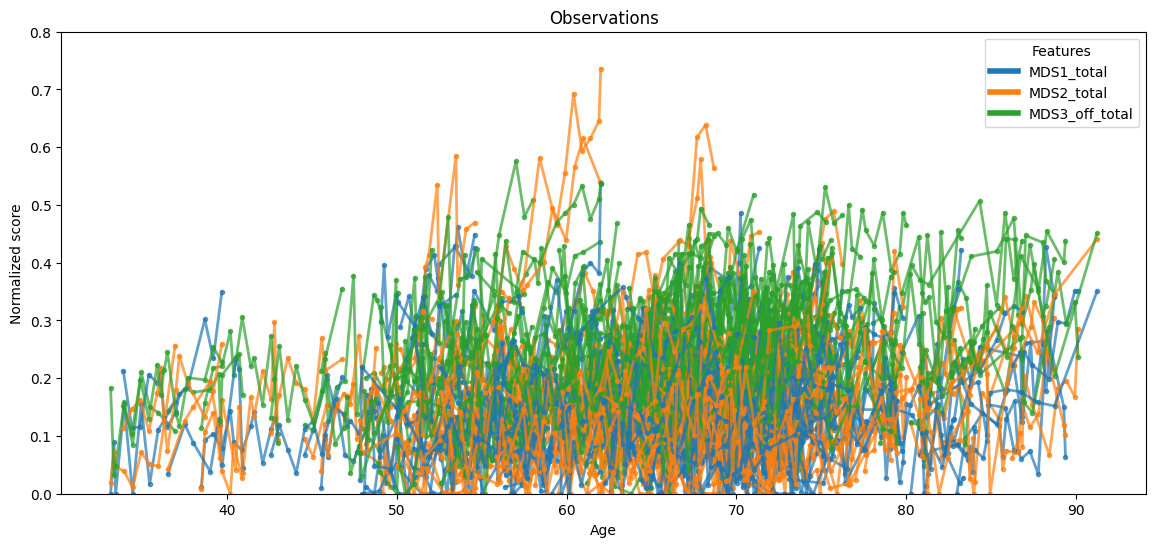

In [8]:
ax = leaspy_plotting.patient_observations(data_train, alpha=0.7, figsize=(14, 6))
ax.set_ylim(0, 0.8)  # The y-axis is adjusted for better visibility.
plt.show()

The model is fitted to the training data using the MCMC-SAEM algorithm.
A fixed seed is used for reproducibility and 100 iterations are performed.



In [9]:
model.fit(
    data_train,
    "mcmc_saem",
    seed=0,
    n_iter=100,
    progress_bar=False,
)

 ==> Setting seed to 0


/Users/jv.martini/Documents/leaspy_examples/.venv/lib/python3.9/site-packages/torch/__init__.py:696: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/tensor/python_tensor.cpp:453.)
  _C._set_default_tensor_type(t)



Fit with `mcmc_saem` took: 3s


The average trajectory estimated by the model is displayed.
This figure shows the mean disease progression curves for all features.



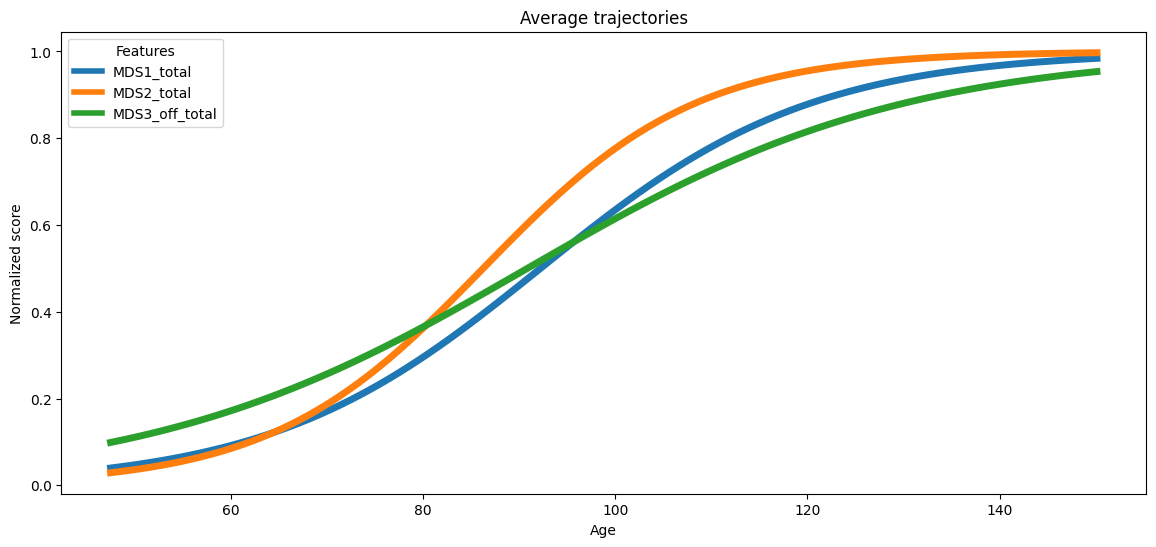

In [10]:
ax = leaspy_plotting.average_trajectory(
    alpha=1, figsize=(14, 6), n_std_left=2, n_std_right=8
)
plt.show()

Individual parameters are obtained for the test data using the personalization step.



In [11]:
ip = model.personalize(data_test, "scipy_minimize", seed=0, progress_bar=False)

 ==> Setting seed to 0


/Users/jv.martini/Documents/leaspy_examples/.venv/lib/python3.9/site-packages/leaspy/algo/personalize/scipy_minimize.py:631: UserWarning: In `scipy_minimize` you requested `use_jacobian=True` but it is not implemented in your model test-model. Falling back to `use_jacobian=False`...
  warnings.warn(



Personalize with `scipy_minimize` took: 22s


The test data with individually re-parametrized ages is plotted below.



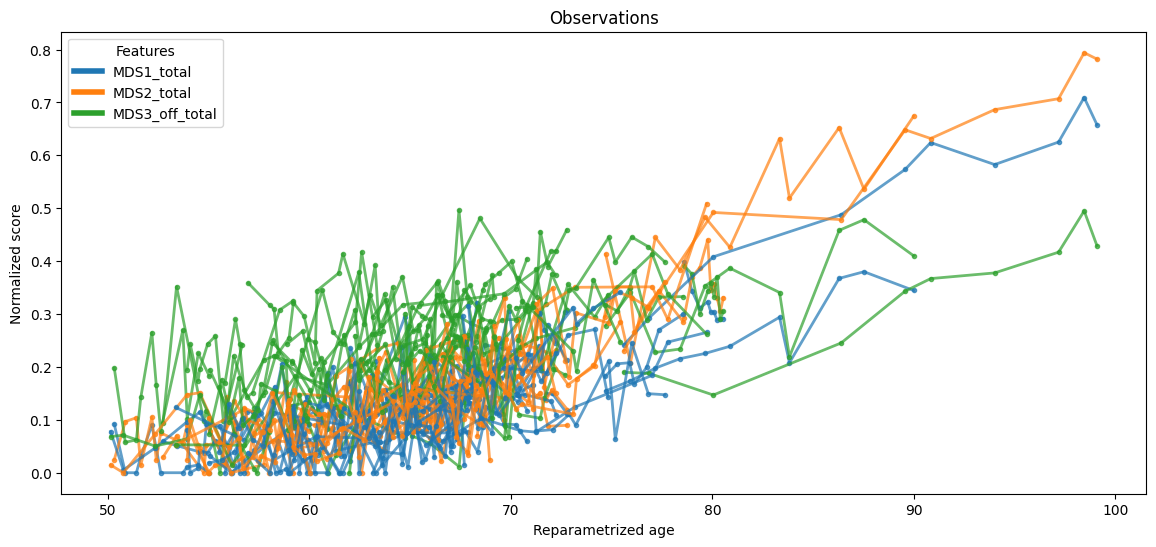

In [12]:
ax = leaspy_plotting.patient_observations_reparametrized(
    data_test, ip, alpha=0.7, linestyle="-", figsize=(14, 6)
)
plt.show()

The test data with the true ages (without re-parametrization) is plotted below.



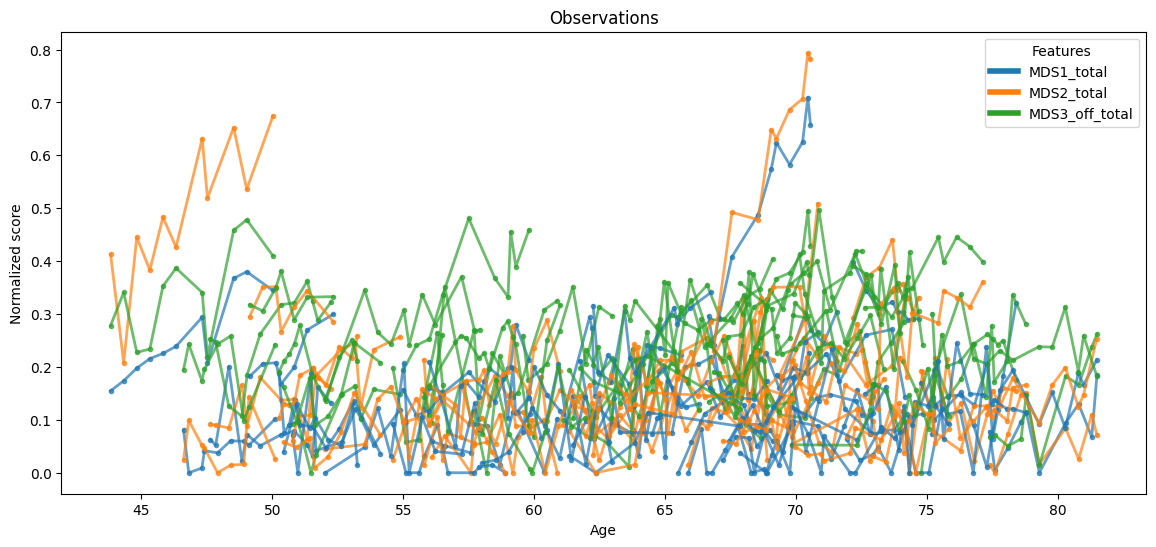

In [13]:
ax = leaspy_plotting.patient_observations(
    data_test,
    alpha=0.7,
    linestyle="-",
    figsize=(14, 6),
)
plt.show()

Observations for a specific subject are extracted to demonstrate reconstruction.



In [14]:
import numpy as np

observations = df_test.loc["GS-187"]
print(f"Seen ages: {observations.index.values}")
print("Individual Parameters : ", ip["GS-187"])

timepoints = np.linspace(60, 100, 100)
reconstruction = model.estimate({"GS-187": timepoints}, ip)

Seen ages: [61.34811783 62.34811783 63.84811783 64.34812164 67.84812164 68.34812164
 69.34812164 69.84812164 70.84812164 71.34812164 71.84812164 72.34812164
 72.84812164 73.34812164]
Individual Parameters :  {'sources': [1.3108469247817993, 0.7215090394020081], 'tau': [73.46849822998047], 'xi': [0.06800808012485504]}


The reconstructed trajectory along with the actual observations for selected subjects is displayed.



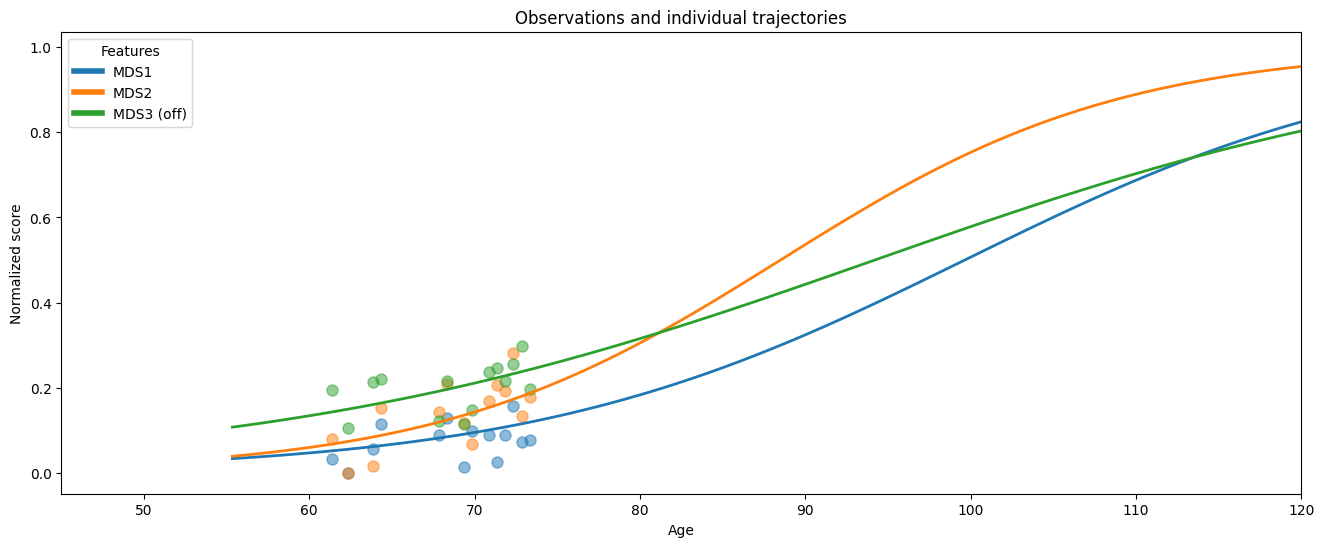

In [15]:
ax = leaspy_plotting.patient_trajectories(
    data_test,
    ip,
    patients_idx=["GS-187"],
    labels=["MDS1", "MDS2", "MDS3 (off)"],
    alpha=1,
    linestyle="-",
    linewidth=2,
    markersize=8,
    obs_alpha=0.5,
    figsize=(16, 6),
    factor_past=0.5,
    factor_future=5,
)
ax.set_xlim(45, 120)
plt.show()